# Day 11: Your First Neural Network — MLP on MNIST 🎉

> **Goal:** Build a multi-layer perceptron (MLP) from scratch, train it end-to-end on MNIST, evaluate accuracy, and visualise results.

---

## The Big Picture

Today we combine everything from Days 1–10:

1. **Load data** (Day 10) → MNIST via `DataLoader`
2. **Define model** (Day 8) → `nn.Module` with `nn.Linear` layers
3. **Choose loss & optimizer** (Day 9) → `CrossEntropyLoss` + `Adam`
4. **Train** (Day 8) → the canonical loop
5. **Evaluate** → accuracy on the test set

By the end, you'll have a model that recognizes handwritten digits with >97% accuracy.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

torch.manual_seed(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


---
## 1. Prepare the Data

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
print(transform)

full_train = torchvision.datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# 80/20 train/val split
train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_data, val_data = random_split(full_train, [train_size, val_size],
                                     generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 2048
#train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
#val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
#test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=8, pin_memory=True)


print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Compose(
    ToTensor()
    Normalize(mean=(0.1307,), std=(0.3081,))
)
Train: 48000, Val: 12000, Test: 10000
Train batches: 24, Val batches: 6, Test batches: 5


---
## 2. Define the MLP Model

An MLP for images:
1. **Flatten** the 28×28 image into a vector of 784
2. Pass through **hidden layers** with ReLU activations
3. Output **10 logits** (one per digit)

```
Input (784) → Linear(784, 256) → ReLU → Linear(256, 128) → ReLU → Linear(128, 10)
```

In [4]:
class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden1=256, hidden2=128, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()  # (B, 1, 28, 28) → (B, 784)
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


model = MLP().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 235,146


---
## 3. Loss Function & Optimizer

In [5]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
print(model.parameters())

<generator object Module.parameters at 0x118c9b680>


---
## 4. Training & Evaluation Functions

In [6]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Forward
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

---
## 5. Train! 🚀

In [7]:
NUM_EPOCHS = 20

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.2%} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.2%}")

/Users/pengzhao/Documents/Projects/DL_learning/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch  1/20 | Train Loss: 0.9812  Acc: 73.80% | Val Loss: 0.3931  Acc: 88.38%
Epoch  2/20 | Train Loss: 0.3270  Acc: 90.44% | Val Loss: 0.3042  Acc: 90.97%
Epoch  3/20 | Train Loss: 0.2470  Acc: 92.91% | Val Loss: 0.2385  Acc: 93.09%
Epoch  4/20 | Train Loss: 0.1977  Acc: 94.37% | Val Loss: 0.2055  Acc: 93.95%
Epoch  5/20 | Train Loss: 0.1672  Acc: 95.22% | Val Loss: 0.1816  Acc: 94.72%
Epoch  6/20 | Train Loss: 0.1460  Acc: 95.85% | Val Loss: 0.1625  Acc: 95.18%
Epoch  7/20 | Train Loss: 0.1274  Acc: 96.30% | Val Loss: 0.1491  Acc: 95.61%
Epoch  8/20 | Train Loss: 0.1113  Acc: 96.83% | Val Loss: 0.1389  Acc: 95.86%
Epoch  9/20 | Train Loss: 0.0989  Acc: 97.14% | Val Loss: 0.1316  Acc: 96.09%
Epoch 10/20 | Train Loss: 0.0902  Acc: 97.32% | Val Loss: 0.1222  Acc: 96.37%
Epoch 11/20 | Train Loss: 0.0797  Acc: 97.74% | Val Loss: 0.1119  Acc: 96.58%
Epoch 12/20 | Train Loss: 0.0701  Acc: 98.03% | Val Loss: 0.1083  Acc: 96.86%
Epoch 13/20 | Train Loss: 0.0644  Acc: 98.17% | Val Loss: 0.1058

### Training Curves

Plotting loss and accuracy over epochs helps you diagnose training. **What to look for:**
- Both curves should improve and eventually plateau
- If train keeps improving but val doesn't → overfitting (we'll fix this on Day 12)

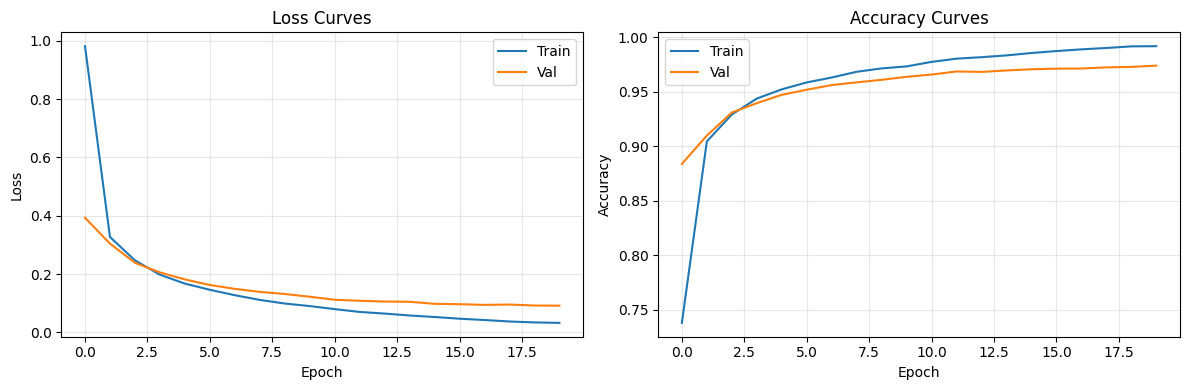

In [8]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"], label="Val")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss Curves")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"], label="Val")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy Curves")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Test Set Evaluation

In [9]:
test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)
print(f"\n🎯 Test Accuracy: {test_acc:.2%}")
print(f"   Test Loss:     {test_loss:.4f}")


🎯 Test Accuracy: 97.60%
   Test Loss:     0.0781


---
## 7. Confusion Matrix

/Users/pengzhao/Documents/Projects/DL_learning/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


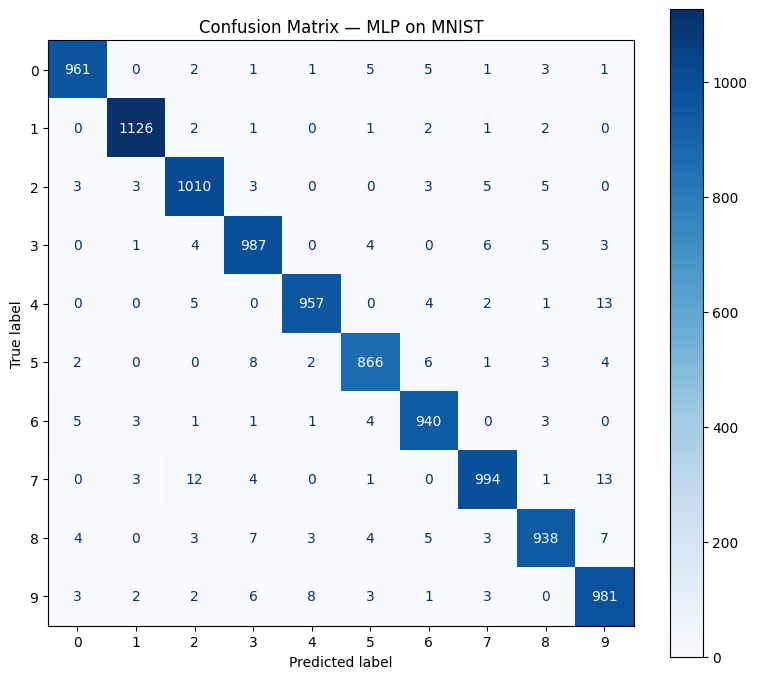

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect all predictions
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=list(range(10)))

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix — MLP on MNIST")
plt.tight_layout()
plt.show()

---
## 8. Visualize Predictions

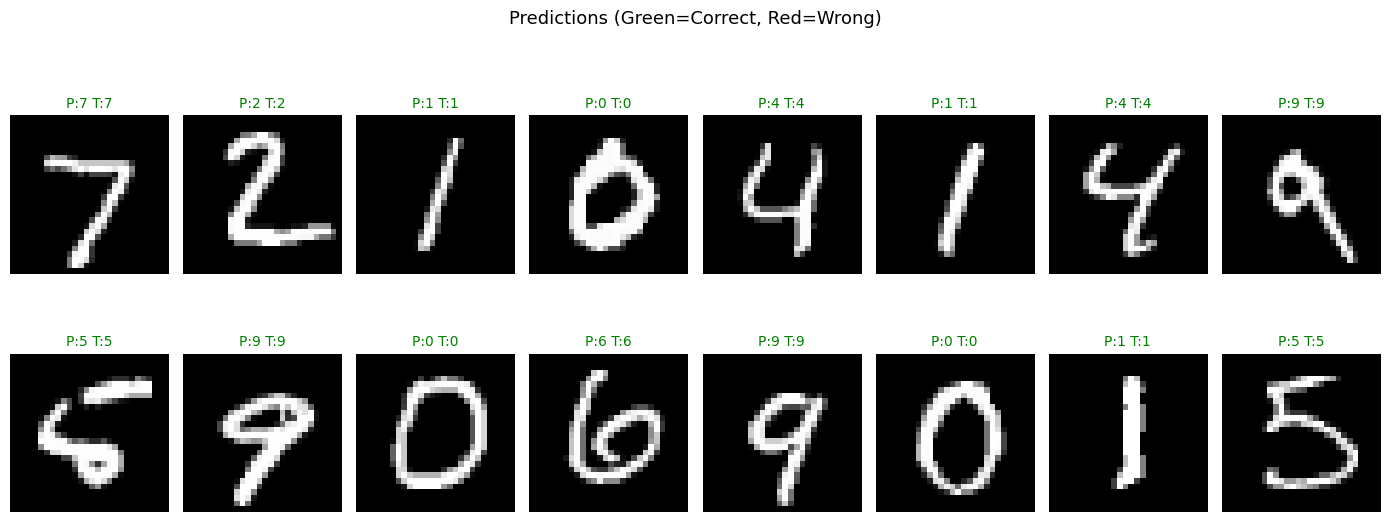

In [10]:
# Show some predictions
fig, axes = plt.subplots(2, 8, figsize=(14, 6))
model.eval()

for i, ax in enumerate(axes.flat):
    img, true_label = test_data[i]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).argmax(1).item()

    ax.imshow(img.squeeze(), cmap="gray")
    color = "green" if pred == true_label else "red"
    ax.set_title(f"P:{pred} T:{true_label}", color=color, fontsize=10)
    ax.axis("off")

plt.suptitle("Predictions (Green=Correct, Red=Wrong)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 🧪 Exercises

### Exercise 1: Deeper network
Add a third hidden layer (e.g., 784 → 512 → 256 → 128 → 10). Does it improve accuracy? How many more parameters does it add?

### Exercise 2: Different optimizers
Train the same model with SGD (lr=0.01, momentum=0.9). Compare training curves with Adam.

### Exercise 3: Find the misclassified
Find and display 16 images that the model gets *wrong*. Are there patterns in what it confuses?

### Exercise 4: Per-class accuracy
Compute accuracy for each digit separately. Which digit is hardest to classify?

In [ ]:
# Exercise 1: Your code here

In [ ]:
# Exercise 2: Your code here

/Users/pengzhao/Documents/Projects/DL_learning/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


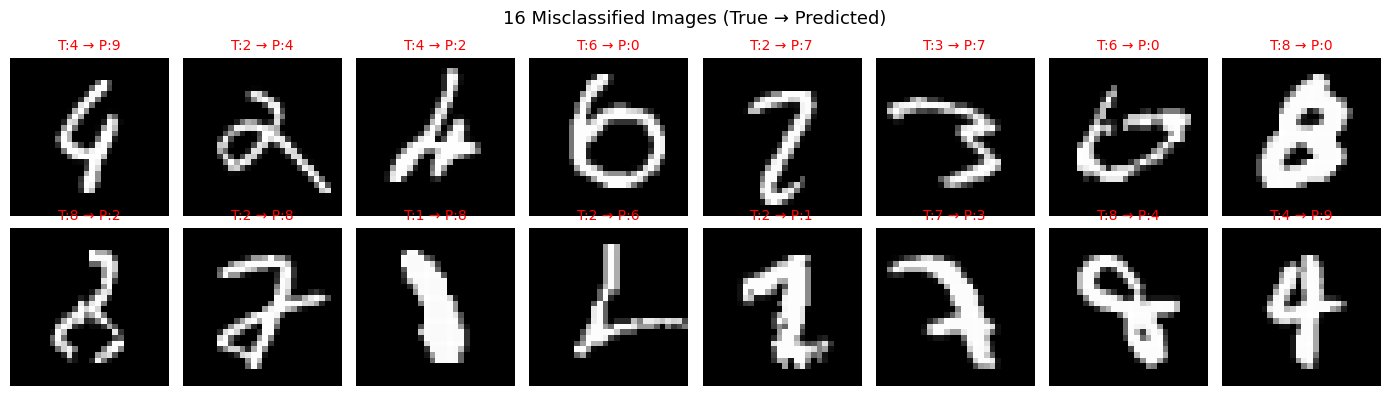

Misclassification pairs (True → Predicted):
  0 mistaken as 2: 3 times
  0 mistaken as 3: 1 times
  0 mistaken as 5: 3 times
  0 mistaken as 6: 5 times
  0 mistaken as 7: 2 times
  0 mistaken as 8: 3 times
  0 mistaken as 9: 1 times
  1 mistaken as 2: 1 times
  1 mistaken as 3: 1 times
  1 mistaken as 5: 1 times
  1 mistaken as 6: 2 times
  1 mistaken as 7: 2 times
  1 mistaken as 8: 4 times
  2 mistaken as 0: 1 times
  2 mistaken as 1: 4 times
  2 mistaken as 3: 4 times
  2 mistaken as 4: 3 times
  2 mistaken as 6: 3 times
  2 mistaken as 7: 5 times
  2 mistaken as 8: 9 times
  3 mistaken as 0: 1 times
  3 mistaken as 2: 2 times
  3 mistaken as 5: 2 times
  3 mistaken as 7: 6 times
  3 mistaken as 8: 3 times
  3 mistaken as 9: 1 times
  4 mistaken as 0: 1 times
  4 mistaken as 2: 5 times
  4 mistaken as 6: 4 times
  4 mistaken as 7: 2 times
  4 mistaken as 8: 1 times
  4 mistaken as 9: 18 times
  5 mistaken as 0: 2 times
  5 mistaken as 3: 7 times
  5 mistaken as 4: 1 times
  5 mistak

In [11]:
# Exercise 3: Find and display 16 misclassified images
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

misclassified = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(1).cpu()
        for i in range(len(labels)):
            if preds[i] != labels[i]:
                misclassified.append((images[i].cpu(), labels[i], preds[i]))
            if len(misclassified) >= 16:
                break
        if len(misclassified) >= 16:
            break

for i, (ax, (img, true_label, pred_label)) in enumerate(zip(axes.flat, misclassified)):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"T:{true_label} → P:{pred_label}", color="red", fontsize=10)
    ax.axis("off")

plt.suptitle("16 Misclassified Images (True → Predicted)", fontsize=13)
plt.tight_layout()
plt.show()

# Optional: Show the distribution of misclassifications
misclass_counts = torch.zeros(10, 10, dtype=torch.int32)
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(1).cpu()
        for i in range(len(labels)):
            if preds[i] != labels[i]:
                misclass_counts[labels[i], preds[i]] += 1

print("Misclassification pairs (True → Predicted):")
for true_digit in range(10):
    for pred_digit in range(10):
        count = misclass_counts[true_digit, pred_digit].item()
        if count > 0:
            print(f"  {true_digit} mistaken as {pred_digit}: {count} times")

Per-digit accuracy:

Digit    Correct    Total    Accuracy  
------------------------------------
0        962        980      98.16%
1        1124       1135     99.03%
2        1003       1032     97.19%
3        995        1010     98.51%
4        951        982      96.84%
5        872        892      97.76%
6        932        958      97.29%
7        1002       1028     97.47%
8        944        974      96.92%
9        976        1009     96.73%

🔴 Hardest digit: 9 (accuracy: 96.73%)
🟢 Easiest digit: 1 (highest correct count)


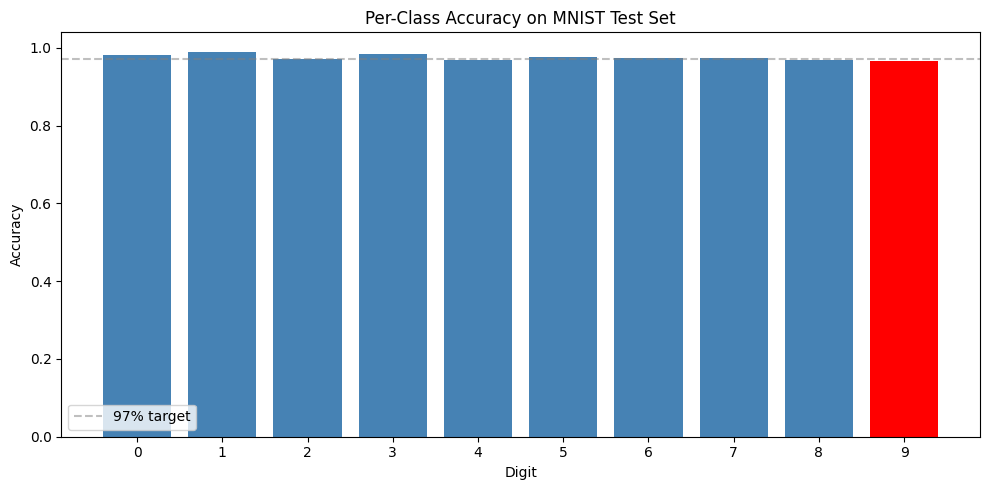

In [12]:
# Exercise 4: Per-class accuracy
class_correct = torch.zeros(10, dtype=torch.int32)
class_total = torch.zeros(10, dtype=torch.int32)

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(1).cpu()
        for i in range(len(labels)):
            class_total[labels[i]] += 1
            if preds[i] == labels[i]:
                class_correct[labels[i]] += 1

print("Per-digit accuracy:\n")
print(f"{'Digit':<8} {'Correct':<10} {'Total':<8} {'Accuracy':<10}")
print("-" * 36)
worst_digit = 0
worst_acc = 1.0
for digit in range(10):
    acc = class_correct[digit].item() / class_total[digit].item()
    if acc < worst_acc:
        worst_acc = acc
        worst_digit = digit
    print(f"{digit:<8} {class_correct[digit].item():<10} {class_total[digit].item():<8} {acc:.2%}")

print(f"\n🔴 Hardest digit: {worst_digit} (accuracy: {worst_acc:.2%})")
print(f"🟢 Easiest digit: {class_correct.argmax().item()} (highest correct count)")

# Bar chart of per-class accuracy
accuracies = [class_correct[d].item() / class_total[d].item() for d in range(10)]
plt.figure(figsize=(10, 5))
colors = ['red' if d == worst_digit else 'steelblue' for d in range(10)]
plt.bar(range(10), accuracies, color=colors)
plt.axhline(y=0.97, color='gray', linestyle='--', alpha=0.5, label='97% target')
plt.xlabel("Digit")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy on MNIST Test Set")
plt.xticks(range(10))
plt.legend()
plt.tight_layout()
plt.show()

---
## 📝 Key Takeaways

| Concept | Summary |
|---|---|
| **MLP** | Flatten image → stack of Linear + ReLU → output logits |
| **Flatten** | Images must be reshaped from (C,H,W) to a 1D vector for an MLP |
| **Training loop** | forward → loss → zero_grad → backward → step |
| **Train/Val/Test** | Train on train, tune on val, report on test |
| **Confusion matrix** | Shows exactly which classes get confused |
| **~97%+ accuracy** | Achievable with a simple MLP on MNIST! |

**Limitation of MLPs for images:** Flattening throws away spatial structure. A pixel's neighbors carry important information. CNNs (Day 16+) will fix this!

**Tomorrow:** We'll learn about overfitting and regularization — how to make sure your model generalizes.